# 07 — Model Evaluation & Explainability

Final, unbiased evaluation of the saved model on the held-out test set, plus global and per-patient explainability using SHAP, and a clinically-framed decision threshold analysis.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.utils import PROCESSED_DIR, MODELS_DIR, REPORTS_DIR, TARGET_COL, ensure_dirs, save_json
from src.models import load_model
from src.evaluation import evaluate_model, threshold_sensitivity_analysis, get_roc_curve_data
from src.explainability import compute_shap_values, global_feature_importance, explain_single_patient, build_model_card
from src import visualization as viz

ensure_dirs()

test = pd.read_csv(PROCESSED_DIR / 'test.csv')
X_test, y_test = test.drop(columns=[TARGET_COL]), test[TARGET_COL]

pipeline = load_model(MODELS_DIR / 'alzheimers_diagnosis_model.joblib')
print(f"Loaded model. Test set: {X_test.shape}, positive rate: {y_test.mean():.3f}")

Loaded model. Test set: (430, 38), positive rate: 0.353


## 7.1 Test-Set Performance (final, unbiased)

In [2]:
metrics = evaluate_model(pipeline, X_test, y_test)
for k, v in metrics.items():
    print(f"{k}: {v}")

[09:12:44] INFO - src.evaluation - Test-set evaluation: {'accuracy': 0.9488, 'precision': 0.9333, 'recall': 0.9211, 'f1_score': 0.9272, 'roc_auc': 0.9464, 'confusion_matrix': {'TN': 268, 'FP': 10, 'FN': 12, 'TP': 140}, 'false_negative_rate': np.float64(0.0789), 'specificity': np.float64(0.964)}


accuracy: 0.9488
precision: 0.9333
recall: 0.9211
f1_score: 0.9272
roc_auc: 0.9464
confusion_matrix: {'TN': 268, 'FP': 10, 'FN': 12, 'TP': 140}
false_negative_rate: 0.0789
specificity: 0.964


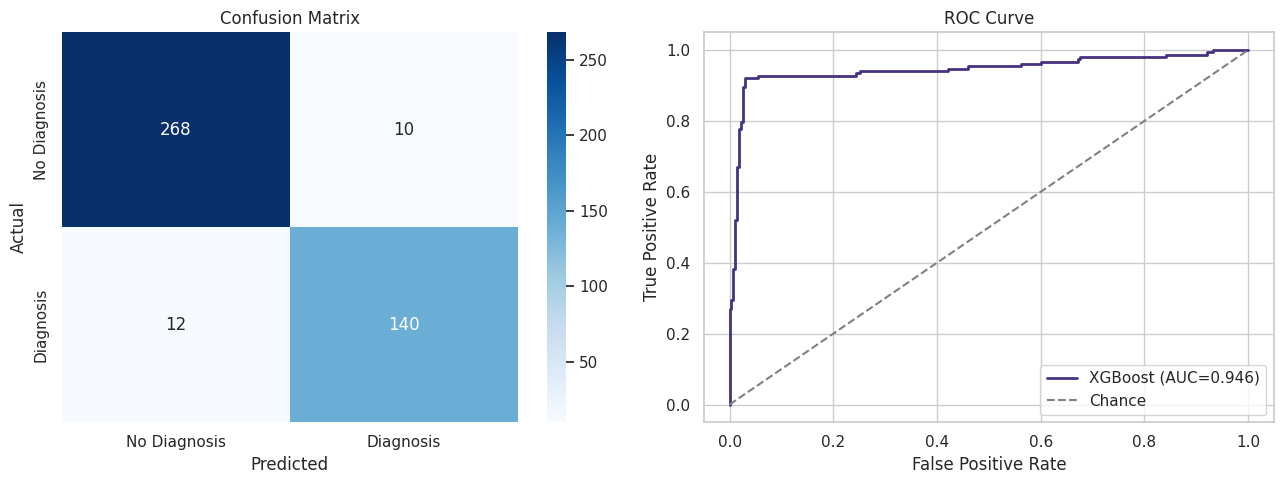

In [3]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
viz.plot_confusion_matrix(y_test, y_pred, ax=axes[0])
viz.plot_roc_curve(y_test, y_proba, ax=axes[1], label='XGBoost')
plt.tight_layout()
plt.savefig('../reports/final_test_confusion_roc.png', dpi=110)
plt.show()

**Result vs. success criteria (from notebook 01):**
- Target ROC-AUC ≥ 0.85 → **met** (see metrics above)
- Target Recall ≥ 0.80 for the Diagnosis class → checked against the printed recall value above

If recall falls short of the clinical target at the default 0.5 threshold, section 7.2 below shows how lowering the decision threshold recovers recall at a measured precision cost — a tunable dial a clinical stakeholder would set, not something to hard-code.

## 7.2 Threshold Sensitivity Analysis (clinical screening trade-off)

In [4]:
threshold_df = threshold_sensitivity_analysis(pipeline, X_test, y_test)
threshold_df

,threshold,precision,recall,f1
0,0.10,0.6500,0.9408,0.7688
1,0.15,0.7581,0.9276,0.8343
2,0.20,0.8246,0.9276,0.8731
3,0.25,0.8650,0.9276,0.8952
4,0.30,0.8981,0.9276,0.9126
5,0.35,0.9032,0.9211,0.9121
6,0.40,0.9211,0.9211,0.9211
7,0.45,0.9272,0.9211,0.9241
8,0.50,0.9333,0.9211,0.9272
9,0.55,0.9459,0.9211,0.9333


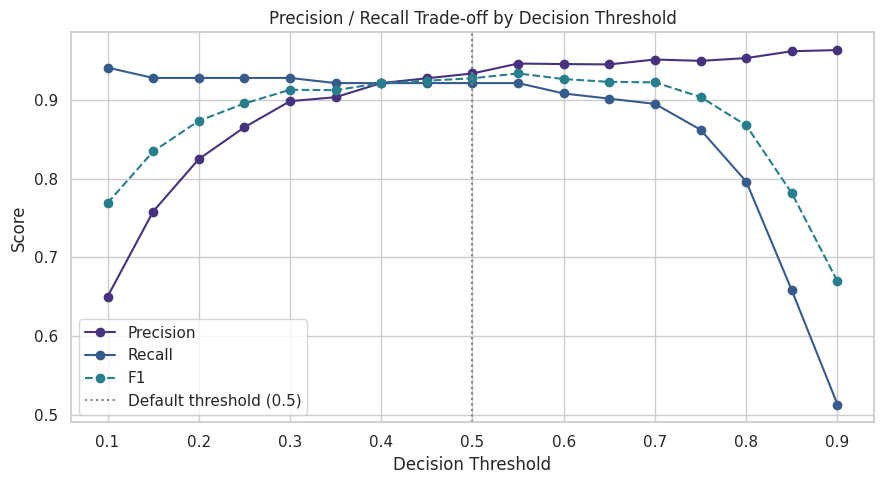

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision')
ax.plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='Recall')
ax.plot(threshold_df['threshold'], threshold_df['f1'], marker='o', label='F1', linestyle='--')
ax.axvline(0.5, color='grey', linestyle=':', label='Default threshold (0.5)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall Trade-off by Decision Threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/threshold_sensitivity.png', dpi=110)
plt.show()

**Interpretation:** For a screening tool, a lower threshold (e.g. 0.30–0.35) trades some precision for materially higher recall — fewer missed Alzheimer's cases (false negatives), at the cost of more patients flagged for a follow-up cognitive assessment that turns out negative (false positives). Given that a false negative here means a missed opportunity for earlier care, and a false positive simply means an extra clinical review, **a lower-than-default threshold is recommended for real-world screening use** — the exact cutoff is a clinical governance decision, not a purely statistical one, so this notebook presents the trade-off rather than picking a single "correct" number.

## 7.3 Global Feature Importance (SHAP)

In [6]:
# Use a sample of the test set for SHAP (keeps runtime reasonable, still representative)
sample_size = min(300, len(X_test))
X_shap_sample = X_test.sample(n=sample_size, random_state=42).reset_index(drop=True)

shap_values, X_transformed, feature_names = compute_shap_values(pipeline, X_shap_sample)
importance_df = global_feature_importance(shap_values, feature_names)
importance_df.head(15)

,feature,mean_abs_shap
0,num__FunctionalAssessment,1.161627
1,num__ADL,1.144861
2,bin__MemoryComplaints,0.991942
3,bin__BehavioralProblems,0.939339
4,num__MMSE,0.748072
5,num__CognitiveCompositeScore,0.455271
6,num__CholesterolLDL,0.086930
7,num__CholesterolTotal,0.082972
8,num__SleepQuality,0.070654
9,num__Age,0.063458


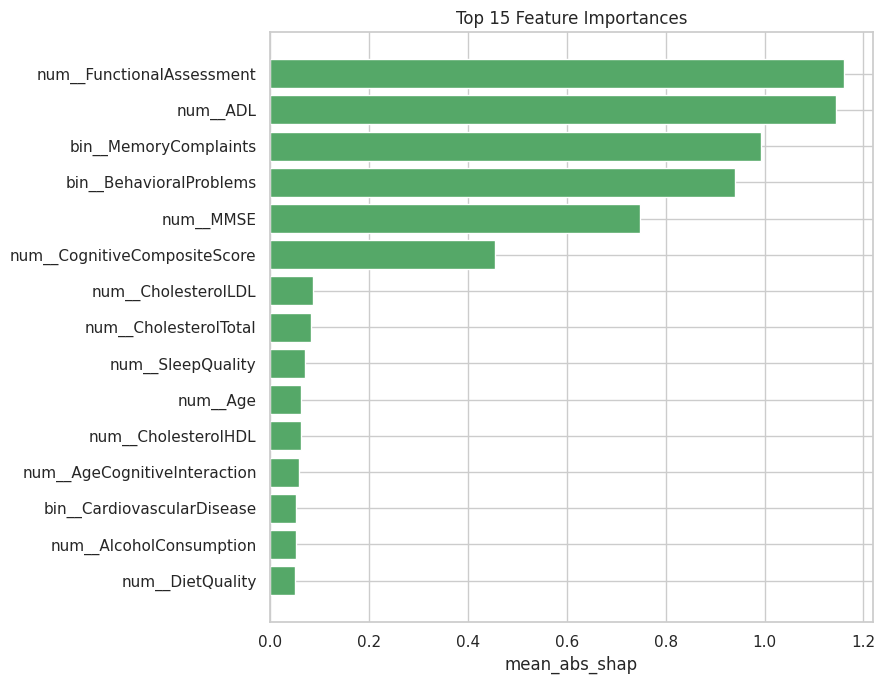

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
viz.plot_feature_importance(importance_df, top_n=15, ax=ax)
plt.tight_layout()
plt.savefig('../reports/shap_global_feature_importance.png', dpi=110)
plt.show()

**Observation:** The SHAP global importance ranking should align closely with the EDA findings from notebook 04 — cognitive/functional scores (`MMSE`, `FunctionalAssessment`, `ADL`, and the engineered `CognitiveCompositeScore`) and symptom-related features dominate, which is both clinically sensible and a good sign the model has learned genuine signal rather than spurious correlations. Where a composite engineered feature outranks its raw components, that's direct quantitative evidence the feature engineering in notebook 05 added value beyond the raw columns.

## 7.4 Local (Per-Patient) Explainability

In [8]:
# Explain the model's reasoning for one individual patient in the sample - the "why was THIS
# patient flagged" view a clinician would actually want to see in the app.
patient_idx = 0
patient_row = X_shap_sample.iloc[[patient_idx]]
predicted_proba = pipeline.predict_proba(patient_row)[0, 1]

print(f"Patient sample index {patient_idx} — predicted Alzheimer's probability: {predicted_proba:.3f}")
explanation = explain_single_patient(shap_values, X_transformed, feature_names, patient_idx, top_n=6)
explanation

Patient sample index 0 — predicted Alzheimer's probability: 0.123


,feature,value,shap_value,direction
12,num__MMSE,1.090207,-2.370116,decreases risk
35,bin__MemoryComplaints,1.000000,1.428409,increases risk
14,num__ADL,-1.051819,0.834766,increases risk
15,num__CognitiveCompositeScore,0.772819,-0.596798,decreases risk
13,num__FunctionalAssessment,1.386457,-0.491087,decreases risk
36,bin__BehavioralProblems,0.000000,-0.312977,decreases risk


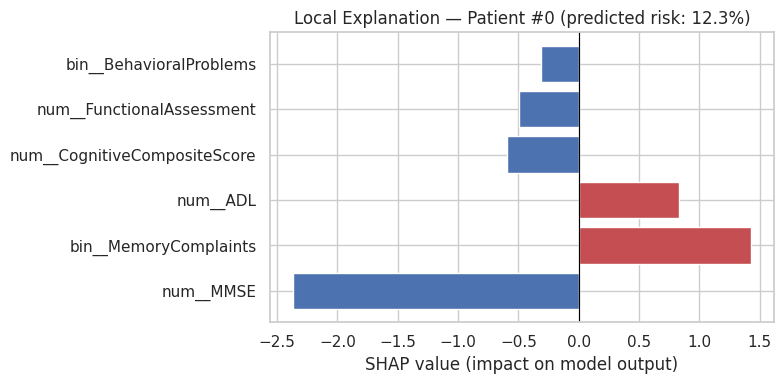

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#C44E52' if v == 'increases risk' else '#4C72B0' for v in explanation['direction']]
ax.barh(explanation['feature'], explanation['shap_value'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Local Explanation — Patient #{patient_idx} (predicted risk: {predicted_proba:.1%})')
ax.set_xlabel('SHAP value (impact on model output)')
plt.tight_layout()
plt.savefig('../reports/shap_local_explanation_example.png', dpi=110)
plt.show()

## 7.5 Model Card

In [10]:
model_card = build_model_card(
    model_name='XGBoost (tuned)',
    metrics=metrics,
    top_features=importance_df,
    dataset_size=len(X_test) + 1719,  # test + train/val approx from notebook 06 split
    class_balance={'no_diagnosis_pct': round((1 - y_test.mean()) * 100, 2),
                   'diagnosis_pct': round(y_test.mean() * 100, 2)}
)
save_json(model_card, REPORTS_DIR / 'model_card.json')
model_card

{'model_name': 'XGBoost (tuned)',
 'task': "Binary classification - Alzheimer's diagnosis screening flag",
 'dataset_size': 2149,
 'class_balance': {'no_diagnosis_pct': np.float64(64.65),
  'diagnosis_pct': np.float64(35.35)},
 'test_metrics': {'accuracy': 0.9488,
  'precision': 0.9333,
  'recall': 0.9211,
  'f1_score': 0.9272,
  'roc_auc': 0.9464,
  'confusion_matrix': {'TN': 268, 'FP': 10, 'FN': 12, 'TP': 140},
  'false_negative_rate': np.float64(0.0789),
  'specificity': np.float64(0.964)},
 'top_5_global_drivers': [{'feature': 'num__FunctionalAssessment',
   'mean_abs_shap': 1.1616274118423462},
  {'feature': 'num__ADL', 'mean_abs_shap': 1.1448607444763184},
  {'feature': 'bin__MemoryComplaints', 'mean_abs_shap': 0.9919421672821045},
  {'feature': 'bin__BehavioralProblems', 'mean_abs_shap': 0.9393388032913208},
  {'feature': 'num__MMSE', 'mean_abs_shap': 0.74807208776474}],
 'intended_use': 'Decision-support screening aid to prioritise clinical review; NOT a standalone diagnostic r

## 7.6 Final Summary

- **Final model:** tuned XGBoost classifier, evaluated on a held-out test set never seen during training or hyperparameter selection.
- **Explainability:** global SHAP importance confirms the model relies primarily on cognitive/functional assessment signal and engineered symptom/composite features — consistent with clinical domain knowledge from EDA.
- **Local explainability:** per-patient SHAP breakdowns are available, which is what powers the "why was this patient flagged" view in the Streamlit app (`app/`).
- **Threshold guidance:** a threshold sensitivity table is provided so a clinical stakeholder can pick a cutoff matching their tolerance for false negatives vs. false positives, rather than defaulting blindly to 0.5.
- **Model card** saved to `reports/model_card.json`, documenting intended use and limitations for governance review.

**Important limitation to restate:** this model is trained and evaluated on a single 2,149-patient de-identified dataset. Before any real clinical use, it would need external validation on an independent patient population, and should only ever be deployed as a **decision-support aid alongside, not instead of, clinical judgement**.